In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_sampling_histograms_by_cluster(sampling_csv="sampling_batch_96.csv", clusters_csv="experiment_summary_with_clusters.csv"):
    # Read the sampling parameters CSV (it only contains x1,x2,x3,x4)
    df_sampling = pd.read_csv(sampling_csv)
    # Create an "Experiment" column from the row index, formatted as a three-digit string (e.g., "000", "001", etc.)
    df_sampling['Experiment'] = df_sampling.index.map(lambda i: '{:03d}'.format(i))
    
    # Read the clusters CSV, which should contain "Experiment" and "Cluster" columns
    df_clusters = pd.read_csv(clusters_csv)
    # Convert the "Experiment" column in the clusters CSV to a string with zero-padding to three digits
    df_clusters['Experiment'] = df_clusters['Experiment'].astype(str).str.zfill(3)
    
    # Merge the sampling and cluster data on the "Experiment" column
    df_merged = pd.merge(df_sampling, df_clusters[['Experiment', 'Cluster']], on='Experiment', how='inner')
    
    # Identify the unique clusters and define the sampling parameters to plot
    clusters = np.sort(df_merged['Cluster'].unique())
    parameters = ['x1', 'x2', 'x3', 'x4']
    num_clusters = len(clusters)
    
    # Create a grid of subplots: one row per cluster, one column per sampling parameter
    fig, axes = plt.subplots(nrows=num_clusters, ncols=4, figsize=(20, 5 * num_clusters))
    
    # Ensure axes is a 2D array in case there's only one cluster
    if num_clusters == 1:
        axes = axes.reshape(1, -1)
    
    # Loop over each cluster and parameter to create histograms with mean and std annotations
    for i, cluster in enumerate(clusters):
        df_cluster = df_merged[df_merged['Cluster'] == cluster]
        for j, param in enumerate(parameters):
            ax = axes[i, j]
            # Plot histogram for the parameter (bins from 0 to 1)
            ax.hist(df_cluster[param], bins=10, range=(0, 1), edgecolor='black')
            # Calculate mean and standard deviation
            mean_val = df_cluster[param].mean()
            std_val = df_cluster[param].std()
            # Set title with cluster, mean, and standard deviation information
            ax.set_title(f"Cluster {cluster} - {param}\nMean: {mean_val:.3f}, Std: {std_val:.3f}")
            ax.set_xlabel(param)
            ax.set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.savefig("sampling_histograms_by_cluster.png")
    plt.show()


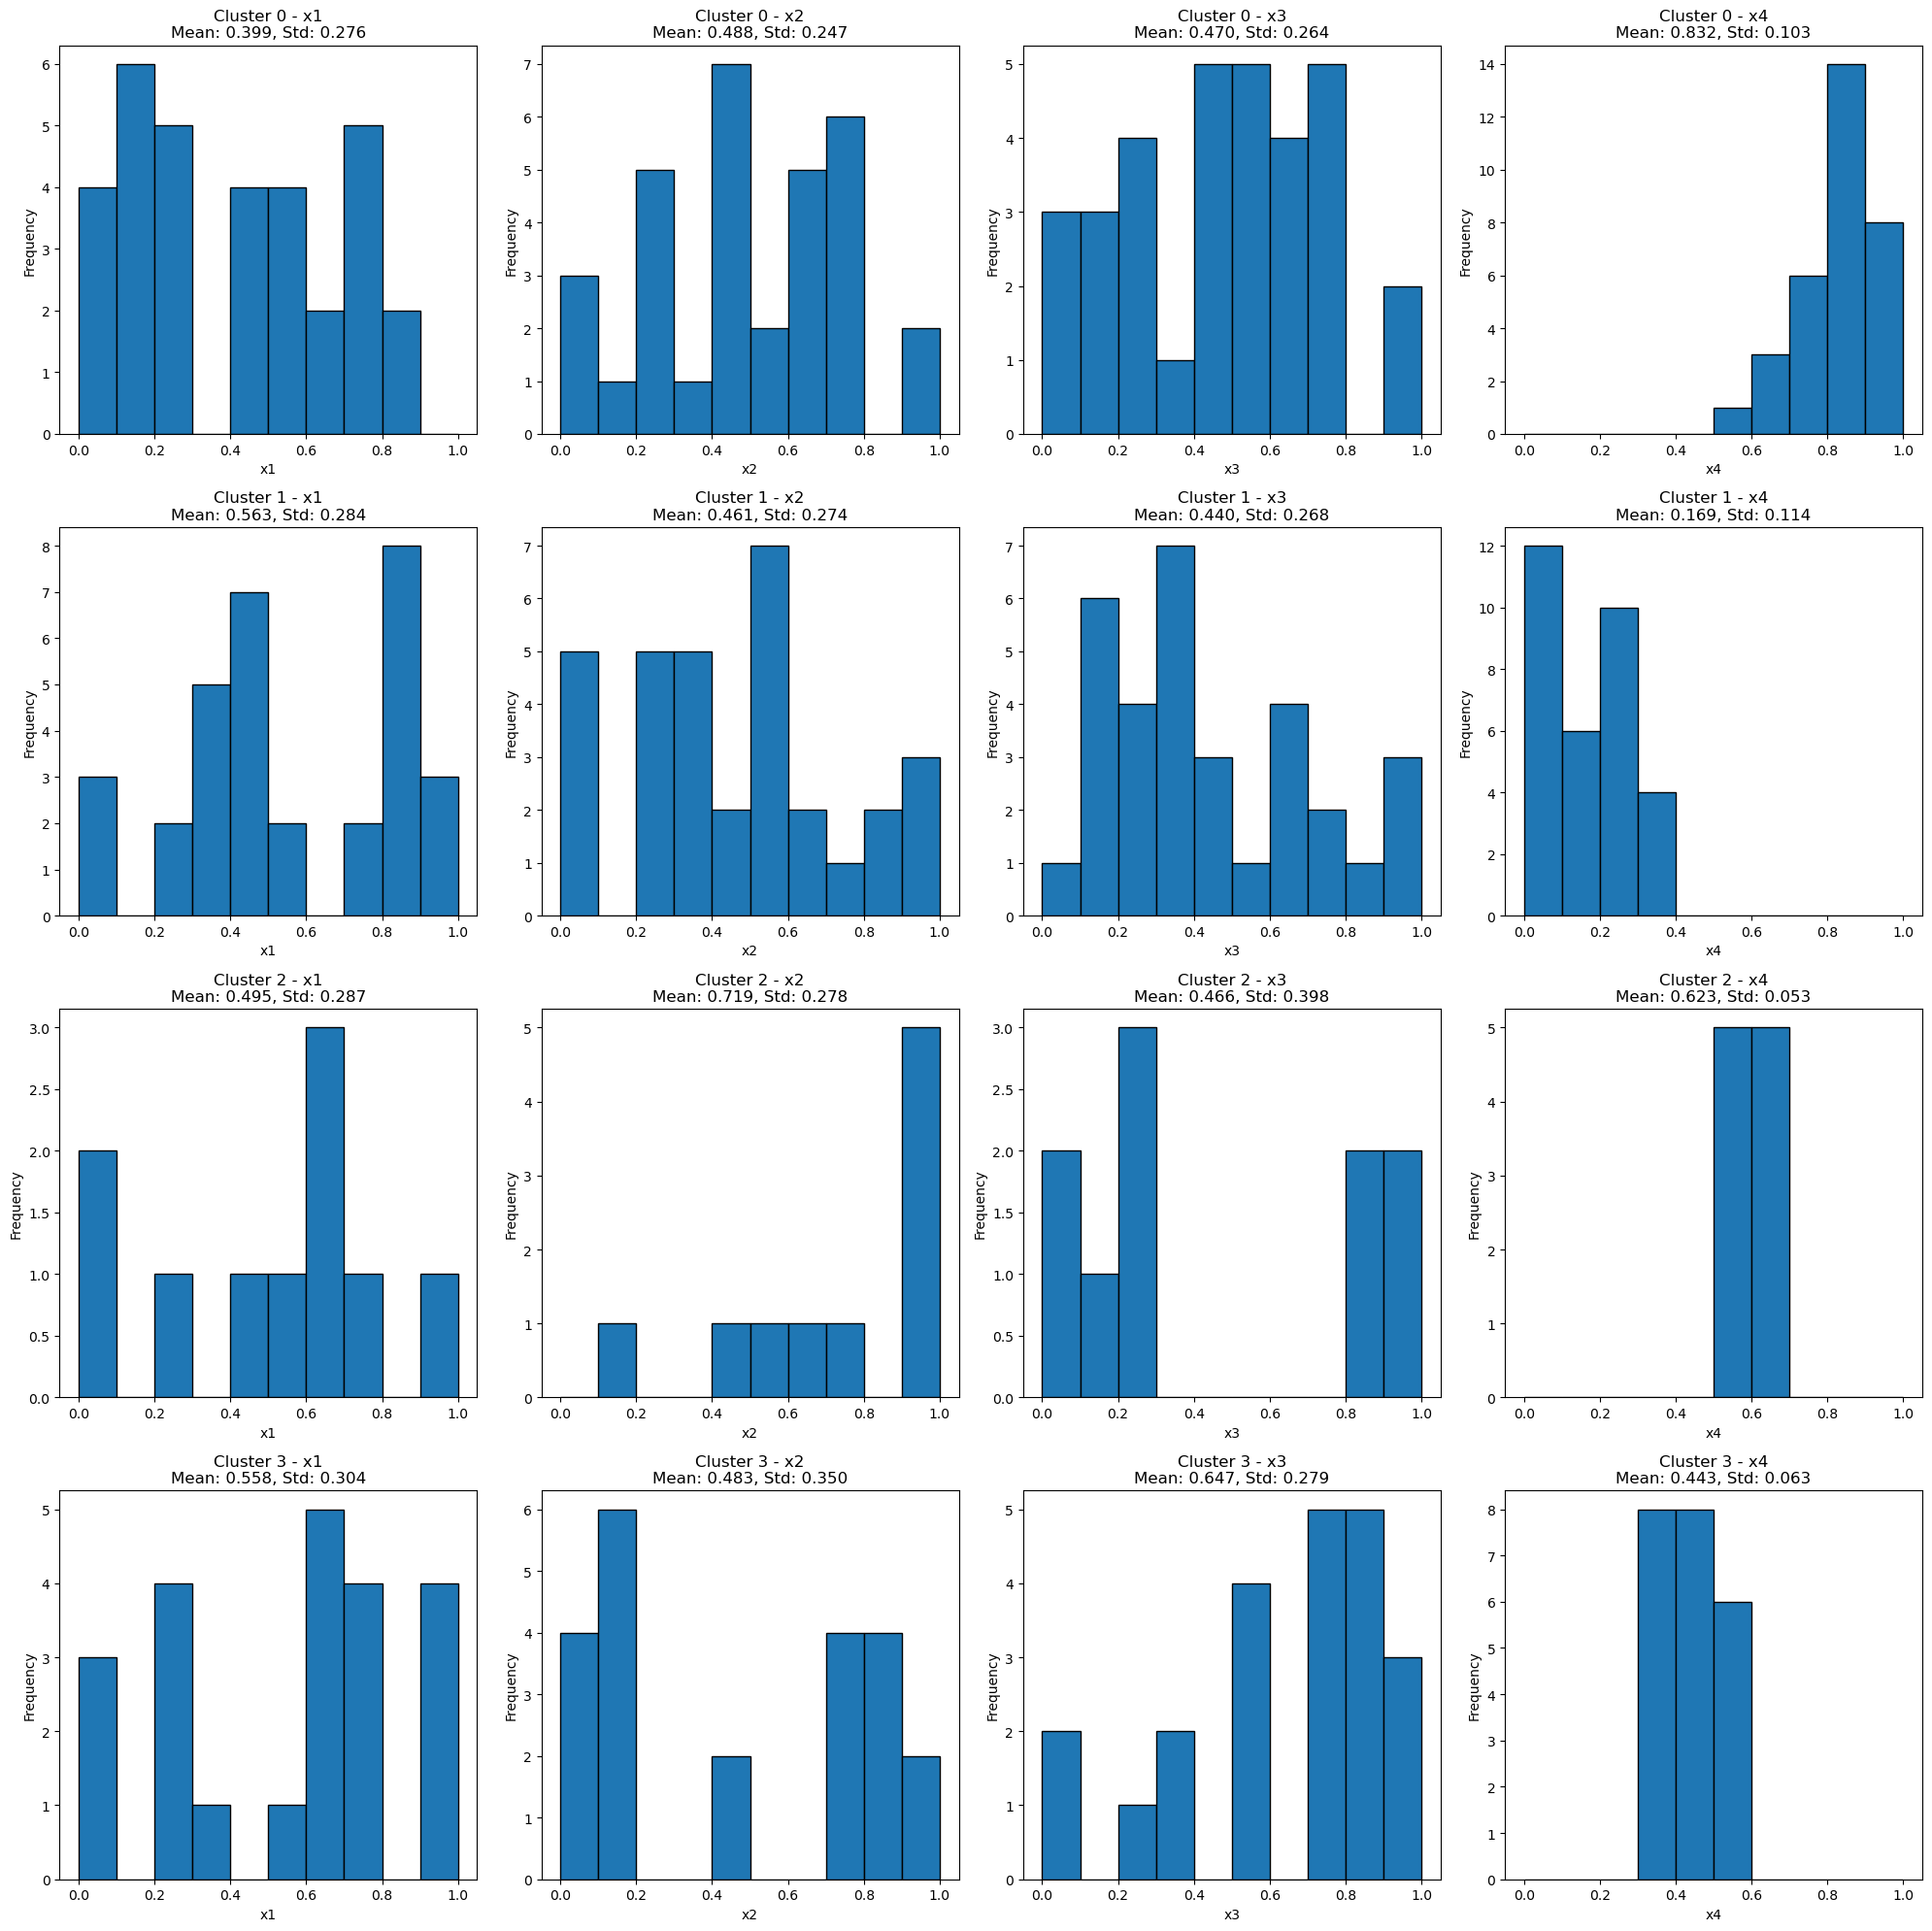

In [4]:
plot_sampling_histograms_by_cluster()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np, ALL_TIMES

def get_max_reflectivity_field(ncfile, variable_name):
    """
    Extracts the 4D field (time, lat, lon) from the WRF file for the given variable,
    computes the maximum reflectivity per pixel over time, and returns the resulting 2D field.
    """
    # Get the full 4D field from the WRF file (time, lat, lon)
    data = to_np(getvar(ncfile, variable_name, timeidx=ALL_TIMES, method="cat"))
    # Compute the maximum reflectivity per pixel (2D field)
    max_field = np.nanmax(data, axis=0)
    return max_field

def plot_mean_max_reflectivity_field(clusters_csv="experiment_summary_with_clusters.csv", variable_name="mdbz"):
    """
    For each experiment in the clusters CSV, loads the corresponding WRF file,
    computes the 2D maximum reflectivity field, groups fields by cluster, computes the mean field
    for each cluster, and plots these mean fields in separate subplots.
    """
    # Read the clusters CSV; it should contain at least 'Experiment' and 'Cluster'
    df_clusters = pd.read_csv(clusters_csv)
    # Ensure the Experiment column is a string with three-digit zero-padding
    df_clusters['Experiment'] = df_clusters['Experiment'].astype(str).str.zfill(3)
    
    # Dictionary to store a list of 2D max reflectivity fields for each cluster
    cluster_fields = {}
    
    # Loop through each experiment in the clusters CSV
    for idx, row in df_clusters.iterrows():
        exp_id = row['Experiment']
        cluster = row['Cluster']
        # Construct the file path (modify the path if needed)
        file_path = f'/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/TEST_Multi_4_vars/{exp_id}/wrfout_{exp_id}.nc'
        try:
            ncfile = Dataset(file_path)
            # Compute the 2D maximum reflectivity field
            max_field = get_max_reflectivity_field(ncfile, variable_name)
            ncfile.close()
            
            # Append the field to the corresponding cluster list
            if cluster not in cluster_fields:
                cluster_fields[cluster] = []
            cluster_fields[cluster].append(max_field)
            print(f"Processed experiment {exp_id} for cluster {cluster}")
        except Exception as e:
            print(f"Error processing experiment {exp_id}: {e}")
            continue

    # Compute the mean 2D field for each cluster by averaging the fields
    mean_fields = {}
    for cluster, fields in cluster_fields.items():
        # Stack all fields along a new axis and compute the mean along that axis
        stacked_fields = np.stack(fields, axis=0)
        mean_field = np.nanmean(stacked_fields, axis=0)
        mean_fields[cluster] = mean_field

    # Plot the mean maximum reflectivity field for each cluster in separate subplots
    clusters = sorted(mean_fields.keys())
    num_clusters = len(clusters)

    # Create one subplot per cluster
    fig, axes = plt.subplots(nrows=num_clusters, ncols=1, figsize=(8, 6 * num_clusters))
    if num_clusters == 1:
        axes = [axes]  # ensure axes is iterable

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        im = ax.imshow(mean_fields[cluster], origin='lower')
        ax.set_title(f"Mean Max Reflectivity (Variable: {variable_name}) for Cluster {cluster}")
        plt.colorbar(im, ax=ax, orientation='vertical', label="Reflectivity")

    plt.tight_layout()
    #plt.savefig("mean_max_reflectivity_field_by_cluster.png")
    plt.show()


Processed experiment 000 for cluster 3
Processed experiment 001 for cluster 2
Processed experiment 002 for cluster 2
Processed experiment 003 for cluster 2
Processed experiment 004 for cluster 1
Processed experiment 005 for cluster 1
Processed experiment 006 for cluster 3
Processed experiment 007 for cluster 3
Processed experiment 008 for cluster 3
Processed experiment 009 for cluster 3
Processed experiment 010 for cluster 3
Processed experiment 011 for cluster 2
Processed experiment 012 for cluster 0
Processed experiment 013 for cluster 0
Processed experiment 014 for cluster 0
Processed experiment 015 for cluster 0
Processed experiment 016 for cluster 0
Processed experiment 017 for cluster 0
Processed experiment 018 for cluster 1
Processed experiment 019 for cluster 1
Processed experiment 020 for cluster 1
Processed experiment 021 for cluster 1
Processed experiment 022 for cluster 1
Processed experiment 023 for cluster 1
Processed experiment 024 for cluster 1
Processed experiment 025 

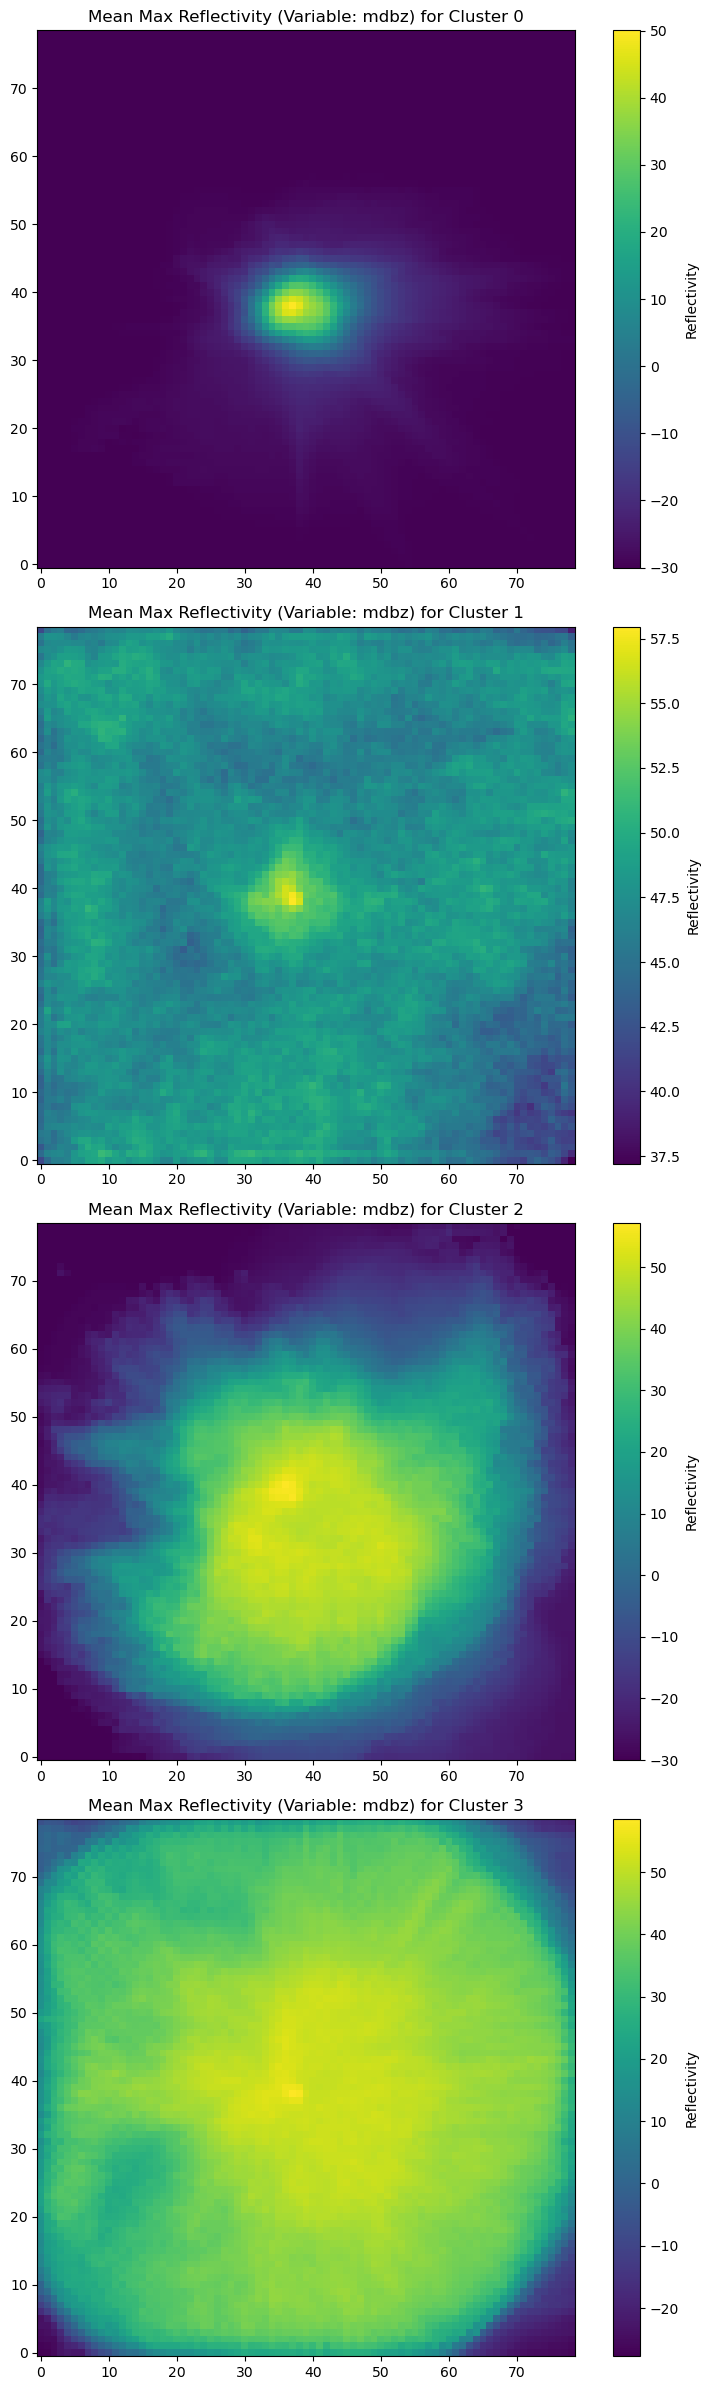

In [7]:
plot_mean_max_reflectivity_field()
